<a href="https://colab.research.google.com/github/kubilaydemirsoy/netflix-recommendation-system/blob/main/netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('netflix.csv')

In [ ]:
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
print(f"Bu veri setinde {df.shape[0]} adet satır (film/dizi) ve {df.shape[1]} adet sütun (özellik) bulunuyor.")

Bu veri setinde 8807 adet satır (film/dizi) ve 12 adet sütun (özellik) bulunuyor.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
display(df.describe())

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
eksik_veriler = df.isnull().sum()
print(eksik_veriler[eksik_veriler > 0])

director      2634
cast           825
country        831
date_added      10
rating           4
duration         3
dtype: int64


In [ ]:
eksik_veriler[eksik_veriler > 0]

,0
director,2634
cast,825
country,831
date_added,10
rating,4
duration,3


In [ ]:
doldurulacak_sutunlar = ['director', 'cast', 'country', 'description', 'listed_in']

In [ ]:
for sutun in doldurulacak_sutunlar:
    # inplace=True: "Bu işlemi kalıcı yap, ana tablomun (df) üzerine yaz" demektir.
    df[sutun].fillna('', inplace=True)

/tmp/ipython-input-3626/3826647613.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[sutun].fillna('', inplace=True)


In [ ]:
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

In [ ]:
print("--- TEMİZLİK SONRASI EKSİK VERİ KONTROLÜ ---")
print(df.isnull().sum())

--- TEMİZLİK SONRASI EKSİK VERİ KONTROLÜ ---
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [ ]:
df.shape[0]

8790

In [ ]:
def kelime_corbasi_yap(satir):
    return satir['title'] + ' ' + satir['director'] + ' ' + satir['cast'] + ' ' + satir['listed_in'] + ' ' + satir['description']

In [ ]:
df['combined_features'] = df.apply(kelime_corbasi_yap, axis=1)

In [ ]:
print(df['combined_features'].iloc[0])

Dick Johnson Is Dead Kirsten Johnson  Documentaries As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.


In [ ]:
display(df[['title', 'combined_features']].head())

,title,combined_features
0,Dick Johnson Is Dead,Dick Johnson Is Dead Kirsten Johnson Document...
1,Blood & Water,"Blood & Water Ama Qamata, Khosi Ngema, Gail M..."
2,Ganglands,"Ganglands Julien Leclercq Sami Bouajila, Tracy..."
3,Jailbirds New Orleans,"Jailbirds New Orleans Docuseries, Reality TV..."
4,Kota Factory,"Kota Factory Mayur More, Jitendra Kumar, Ranj..."


In [ ]:
import re

In [ ]:
def metin_temizle(metin):
    metin = str(metin)

    metin = metin.lower()

    metin = re.sub(r'[^\w\s]', '', metin)

    return metin

In [ ]:
df['combined_features'] = df['combined_features'].apply(metin_temizle)

In [ ]:
print(df['combined_features'].iloc[0])

dick johnson is dead kirsten johnson  documentaries as her father nears the end of his life filmmaker kirsten johnson stages his death in inventive and comical ways to help them both face the inevitable


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vektorizer = TfidfVectorizer(stop_words='english')

In [ ]:
vektor_matrisi = vektorizer.fit_transform(df['combined_features'])

In [ ]:
satir_sayisi, kelime_sayisi = vektor_matrisi.shape

In [ ]:
print(f"Toplam {satir_sayisi} adet film/dizi için çeviri yapıldı.")

Toplam 8790 adet film/dizi için çeviri yapıldı.


In [ ]:
print(f"Toplam {kelime_sayisi} adet birbirinden farklı ve anlamlı kelime öğrenildi!")

Toplam 56274 adet birbirinden farklı ve anlamlı kelime öğrenildi!


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
benzerlik_matrisi = cosine_similarity(vektor_matrisi)

In [ ]:
print(f"Benzerlik Tablosunun Boyutu: {benzerlik_matrisi.shape}")

Benzerlik Tablosunun Boyutu: (8790, 8790)


In [ ]:
print("\nİlk filmin, listedeki ilk 5 filmle olan benzerlik skorları:")
print(benzerlik_matrisi[0][:5])


İlk filmin, listedeki ilk 5 filmle olan benzerlik skorları:
[1.        0.        0.        0.        0.0077937]


In [ ]:
film_fihristi = pd.Series(df.index, index=df['title']).drop_duplicates()

In [ ]:
def film_tavsiye_et(film_adi, benzerlik_beyni=benzerlik_matrisi):
    film_sirasi = film_fihristi[film_adi]
    benzerlik_skorlari = list(enumerate(benzerlik_beyni[film_sirasi]))
    sirali_skorlar = sorted(benzerlik_skorlari, key=lambda x: x[1], reverse=True)
    en_iyi_5_film = sirali_skorlar[1:6]
    tavsiye_edilen_film_indeksleri = [i[0] for i in en_iyi_5_film]
    print(f"🍿 '{film_adi}' filmini sevenler bunları da izledi:")
    print("-" * 50)
    for i, film_ismi in enumerate(df['title'].iloc[tavsiye_edilen_film_indeksleri], 1):
        print(f"{i}. {film_ismi}")

    print("-" * 50)

In [ ]:
film_tavsiye_et('The Matrix')

🍿 'The Matrix' filmini sevenler bunları da izledi:
--------------------------------------------------
1. I AM A KILLER
2. I AM A KILLER: RELEASED
3. Dancing Angels
4. Sophie: A Murder in West Cork
5. Murder Maps
--------------------------------------------------


In [ ]:
def gelismis_tavsiye_et(aranan_film):
    aranan_film_kucuk = aranan_film.lower()
    film_isimleri_kucuk = df['title'].str.lower()

    try:
        film_sirasi = film_isimleri_kucuk[film_isimleri_kucuk == aranan_film_kucuk].index[0]

        benzerlik_skorlari = list(enumerate(benzerlik_matrisi[film_sirasi]))
        sirali_skorlar = sorted(benzerlik_skorlari, key=lambda x: x[1], reverse=True)
        en_iyi_5_film = sirali_skorlar[1:6]
        tavsiye_edilen_film_indeksleri = [i[0] for i in en_iyi_5_film]

        print(f"🍿 '{aranan_film}' aramanız için en iyi tavsiyeler:")
        print("-" * 50)
        for i, film_ismi in enumerate(df['title'].iloc[tavsiye_edilen_film_indeksleri], 1):
            print(f"{i}. {film_ismi}")
        print("-" * 50)

    except IndexError:
        print(f"⚠️ HATA: Üzgünüm, '{aranan_film}' adlı filmi veri setimizde bulamadım.")
        print("Lütfen adını doğru yazdığınızdan veya filmin Netflix'te olduğundan emin olun.")

print("--- TEST 1: KÜÇÜK HARFLE ARAMA ---")
gelismis_tavsiye_et('the matrix')

print("\n--- TEST 2: OLMAYAN FİLM ARAMASI ---")
gelismis_tavsiye_et('Harika Bir Veri Bilimi Serüveni')

--- TEST 1: KÜÇÜK HARFLE ARAMA ---
🍿 'the matrix' aramanız için en iyi tavsiyeler:
--------------------------------------------------
1. I AM A KILLER
2. I AM A KILLER: RELEASED
3. Dancing Angels
4. Sophie: A Murder in West Cork
5. Murder Maps
--------------------------------------------------

--- TEST 2: OLMAYAN FİLM ARAMASI ---
⚠️ HATA: Üzgünüm, 'Harika Bir Veri Bilimi Serüveni' adlı filmi veri setimizde bulamadım.
Lütfen adını doğru yazdığınızdan veya filmin Netflix'te olduğundan emin olun.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [ ]:
sns.set_theme(style="darkgrid")

filmler = df[df['type'] == 'Movie'].copy()
filmler['duration_minutes'] = filmler['duration'].str.replace(' min', '').astype(int)

In [ ]:
korelasyon_matrisi = filmler[['release_year', 'duration_minutes']].corr()

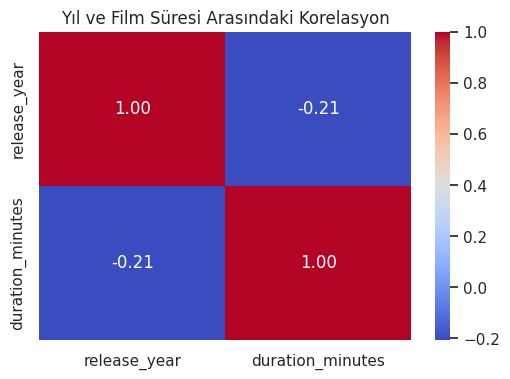

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Yıl ve Film Süresi Arasındaki Korelasyon")
plt.show()

/tmp/ipython-input-3626/1854421610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=en_cok_uretenler.values, y=en_cok_uretenler.index, palette="viridis")


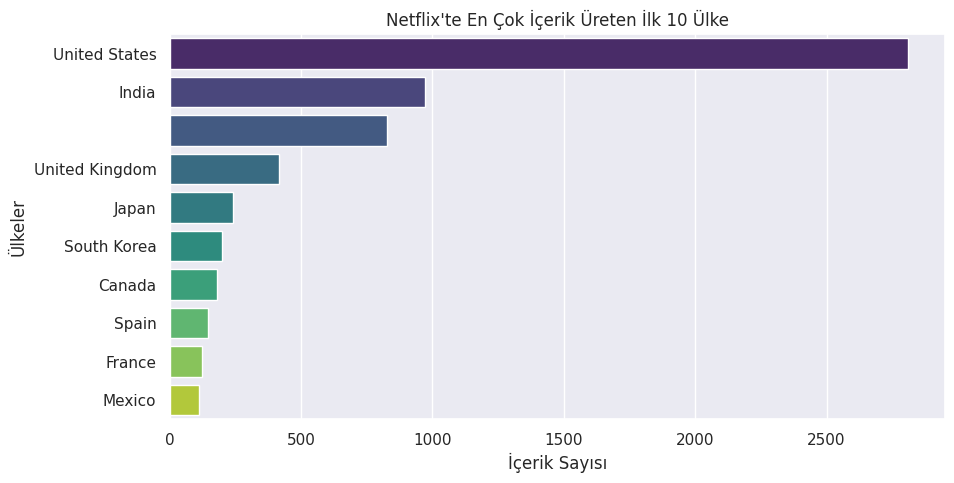

In [ ]:
plt.figure(figsize=(10, 5))
en_cok_uretenler = df['country'].value_counts().head(10)
sns.barplot(x=en_cok_uretenler.values, y=en_cok_uretenler.index, palette="viridis")
plt.title("Netflix'te En Çok İçerik Üreten İlk 10 Ülke")
plt.xlabel("İçerik Sayısı")
plt.ylabel("Ülkeler")
plt.show()

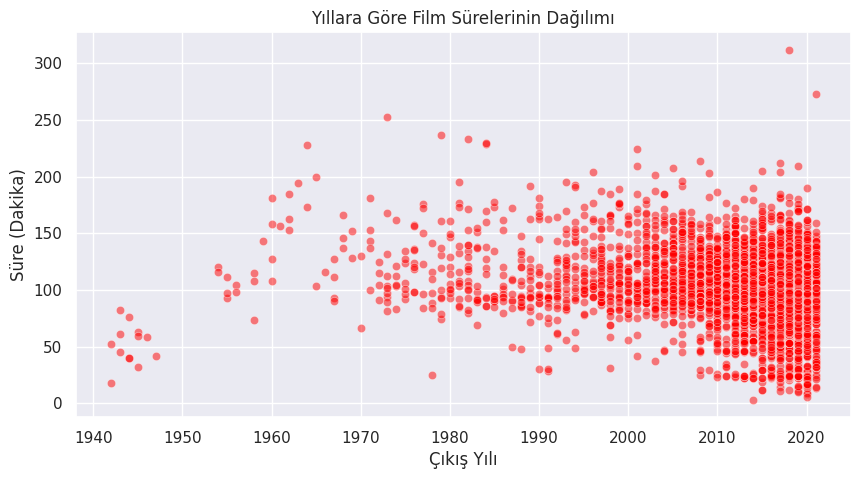

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=filmler, x='release_year', y='duration_minutes', alpha=0.5, color='red')
plt.title("Yıllara Göre Film Sürelerinin Dağılımı")
plt.xlabel("Çıkış Yılı")
plt.ylabel("Süre (Dakika)")
plt.show()

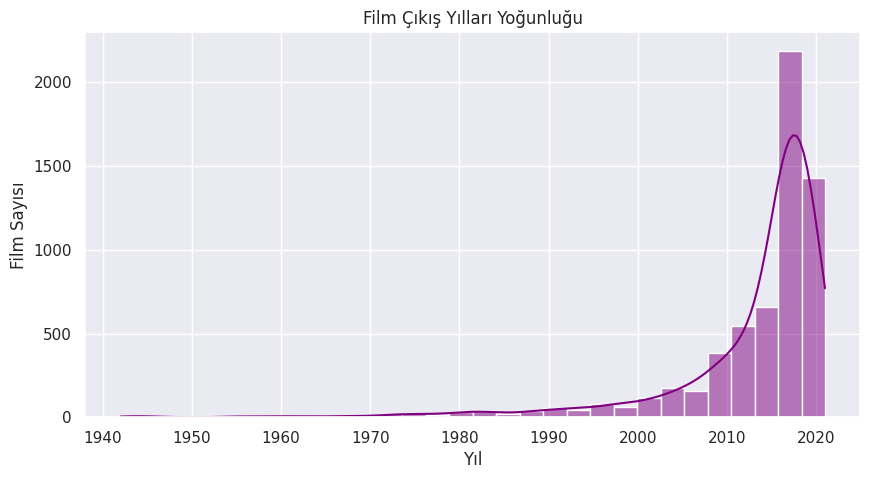

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(filmler['release_year'], bins=30, kde=True, color='purple')
plt.title("Film Çıkış Yılları Yoğunluğu")
plt.xlabel("Yıl")
plt.ylabel("Film Sayısı")
plt.show()

In [ ]:
with open('netflix_benzerlik_modeli.pkl', 'wb') as dosya:
    pickle.dump(benzerlik_matrisi, dosya)

In [ ]:
with open('netflix_veri_tablosu.pkl', 'wb') as dosya:
    pickle.dump(df, dosya)